In [1]:
# ============================================================
# Handwritten Digit Recognition using TensorFlow & Keras
# Activation Function Comparison
# ============================================================

import json
import os
import time
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

# ------------------------------------------------------------
# Random Seed
# ------------------------------------------------------------

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

# ------------------------------------------------------------
# Training Configuration
# ------------------------------------------------------------

EPOCHS = 20
BATCH_SIZE = 128
NUM_CLASSES = 10

# ------------------------------------------------------------
# Create Result Directories
# ------------------------------------------------------------

folders = [
    "results",
    "results/models",
    "results/plots",
    "results/confusion_matrix",
    "results/history"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("=" * 60)
print("Environment Ready")
print("=" * 60)

Environment Ready


In [2]:
# ============================================================
# Load Dataset
# ============================================================

print("\nLoading MNIST Dataset...\n")

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("Training Images :", x_train.shape)
print("Testing Images  :", x_test.shape)

# ============================================================
# Normalize
# ============================================================

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# ============================================================
# One Hot Encoding
# ============================================================

y_train_cat = keras.utils.to_categorical(y_train, NUM_CLASSES)
y_test_cat = keras.utils.to_categorical(y_test, NUM_CLASSES)

print("\nDataset Loaded Successfully")


Loading MNIST Dataset...

Training Images : (60000, 28, 28)
Testing Images  : (10000, 28, 28)



Dataset Loaded Successfully


In [3]:
# ============================================================
# Activation Functions
# ============================================================

ACTIVATIONS = {
    "relu": "relu",
    "tanh": "tanh",
    "sigmoid": "sigmoid",
    "linear": "linear",
    "exponential": "exponential"
}

# ============================================================
# Leaky ReLU
# ============================================================

def leaky_relu():
    return layers.LeakyReLU(negative_slope=0.1)


@keras.utils.register_keras_serializable(package="mnist_experiment")
def clipped_exponential(x):
    """Numerically stable exponential activation."""
    return tf.exp(tf.clip_by_value(x, -10.0, 10.0))

print("\nActivation Functions")

for activation in ACTIVATIONS.keys():
    print("•", activation)

print("• leaky_relu")


Activation Functions
• relu
• tanh
• sigmoid
• linear
• exponential
• leaky_relu


In [4]:
# ============================================================
# Model Builder
# ============================================================

def build_model(activation):

    model = keras.Sequential()

    model.add(layers.Input(shape=(28, 28)))

    model.add(layers.Flatten())

    # -------------------------
    # Layer 1
    # -------------------------

    model.add(layers.Dense(512))

    if activation == "leaky_relu":
        model.add(leaky_relu())
    elif activation == "exponential":
        model.add(layers.Activation(clipped_exponential))
    else:
        model.add(layers.Activation(activation))

    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.30))

    # -------------------------
    # Layer 2
    # -------------------------

    model.add(layers.Dense(256))

    if activation == "leaky_relu":
        model.add(leaky_relu())
    elif activation == "exponential":
        model.add(layers.Activation(clipped_exponential))
    else:
        model.add(layers.Activation(activation))

    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.25))

    # -------------------------
    # Layer 3
    # -------------------------

    model.add(layers.Dense(128))

    if activation == "leaky_relu":
        model.add(leaky_relu())
    elif activation == "exponential":
        model.add(layers.Activation(clipped_exponential))
    else:
        model.add(layers.Activation(activation))

    model.add(layers.BatchNormalization())

    # -------------------------
    # Output Layer
    # -------------------------

    model.add(
        layers.Dense(
            NUM_CLASSES,
            activation="softmax"
        )
    )

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

print("\nModel Builder Ready")


Model Builder Ready


In [5]:
# ============================================================
# Callbacks
# ============================================================

def get_callbacks(name):

    checkpoint = ModelCheckpoint(
        filepath=f"results/models/{name}.keras",
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    )

    reduce_lr = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        verbose=1
    )

    return [
        checkpoint,
        early_stop,
        reduce_lr
    ]


# ============================================================
# Store Results
# ============================================================

results = []

history_dict = {}

print("\n")
print("=" * 70)
print("TRAINING STARTED")
print("=" * 70)

# ============================================================
# Train All Activation Functions
# ============================================================

activation_list = list(ACTIVATIONS.keys())
activation_list.append("leaky_relu")

for activation in activation_list:

    print("\n")
    print("=" * 60)
    print("Activation :", activation)
    print("=" * 60)

    model = build_model(activation)

    start = time.time()

    history = model.fit(

        x_train,
        y_train_cat,

        validation_split=0.20,

        epochs=EPOCHS,

        batch_size=BATCH_SIZE,

        callbacks=get_callbacks(activation),

        verbose=1

    )

    training_time = time.time() - start

    history_dict[activation] = history.history

    with open(f"results/history/{activation}.json", "w", encoding="utf-8") as file:
        json.dump(history.history, file, indent=2)

    # ------------------------------------------
    # Evaluate
    # ------------------------------------------

    loss, accuracy = model.evaluate(
        x_test,
        y_test_cat,
        verbose=0
    )

    # ------------------------------------------
    # Predictions
    # ------------------------------------------

    predictions = model.predict(
        x_test,
        verbose=0
    )

    y_pred = np.argmax(predictions, axis=1)

    # ------------------------------------------
    # Save Detailed Evaluation Artifacts
    # ------------------------------------------

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8, 7))
    plt.imshow(cm, interpolation="nearest", cmap="Blues")
    plt.title(f"{activation.upper()} Confusion Matrix")
    plt.colorbar()
    tick_marks = np.arange(NUM_CLASSES)
    plt.xticks(tick_marks, tick_marks)
    plt.yticks(tick_marks, tick_marks)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")

    threshold = cm.max() / 2.0
    for row in range(NUM_CLASSES):
        for column in range(NUM_CLASSES):
            plt.text(
                column, row, cm[row, column],
                ha="center", va="center",
                color="white" if cm[row, column] > threshold else "black"
            )

    plt.tight_layout()
    plt.savefig(
        f"results/confusion_matrix/{activation}.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.close()

    report = classification_report(
        y_test, y_pred, digits=4, zero_division=0
    )
    with open(
        f"results/confusion_matrix/{activation}_classification_report.txt",
        "w",
        encoding="utf-8"
    ) as file:
        file.write(report)

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted"
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted"
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted"
    )

    # ------------------------------------------
    # Save Results
    # ------------------------------------------

    results.append({

        "Activation": activation,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1 Score": f1,

        "Loss": loss,

        "Training Time": training_time

    })

    print("\nFinished :", activation)

    print("Accuracy  :", round(accuracy,4))
    print("Precision :", round(precision,4))
    print("Recall    :", round(recall,4))
    print("F1 Score  :", round(f1,4))
    print("Loss      :", round(loss,4))
    print("Time      :", round(training_time,2),"seconds")

print("\n")
print("=" * 70)
print("ALL MODELS TRAINED")
print("=" * 70)



TRAINING STARTED


Activation : relu
Epoch 1/20


  1/375 ━━━━━━━━━━━━━━━━━━━━ 7:23 1s/step - accuracy: 0.0859 - loss: 3.1296

 17/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6287 - loss: 1.1719 

 34/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7374 - loss: 0.8407

 51/375 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7884 - loss: 0.6867

...


Epoch 20: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.


375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9980 - loss: 0.0075 - val_accuracy: 0.9833 - val_loss: 0.0656 - learning_rate: 3.1250e-05


Epoch 20: early stopping


Restoring model weights from the end of the best epoch: 15.



Finished : leaky_relu
Accuracy  : 0.9861
Precision : 0.9861
Recall    : 0.9861
F1 Score  : 0.9861
Loss      : 0.054
Time      : 33.48 seconds


ALL MODELS TRAINED


In [6]:
# ============================================================
# Comparison Table
# ============================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

print("\n")
print("=" * 70)
print("FINAL RESULTS")
print("=" * 70)

print(results_df)

results_df.to_csv(
    "results/activation_results.csv",
    index=False
)

print("\nResults saved successfully.")



FINAL RESULTS
    Activation  Accuracy  Precision  Recall  F1 Score      Loss  Training Time
5   leaky_relu    0.9861   0.986117  0.9861  0.986100  0.054016      33.484609
0         relu    0.9848   0.984818  0.9848  0.984804  0.055280      22.451373
1         tanh    0.9825   0.982507  0.9825  0.982493  0.066201      30.161792
2      sigmoid    0.9799   0.979922  0.9799  0.979894  0.066440      31.598295
4  exponential    0.9637   0.965679  0.9637  0.963742  0.309980      32.950322
3       linear    0.9252   0.924977  0.9252  0.924934  0.270695      31.438304

Results saved successfully.



Generating Accuracy/Loss Graphs...


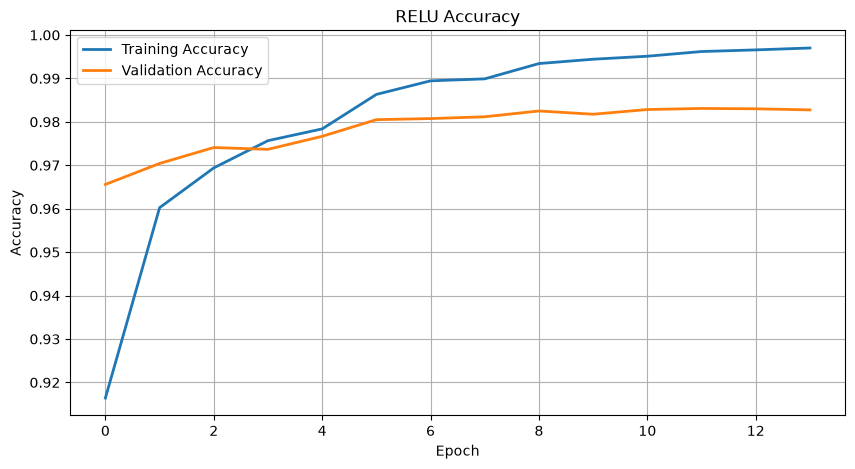

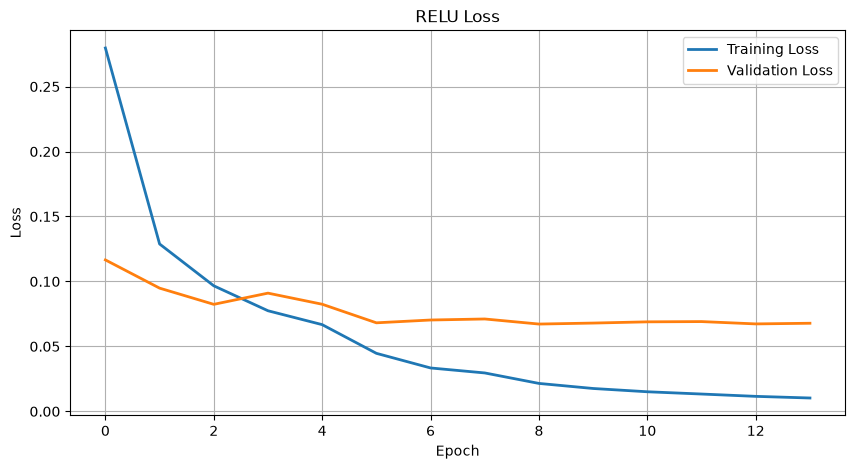

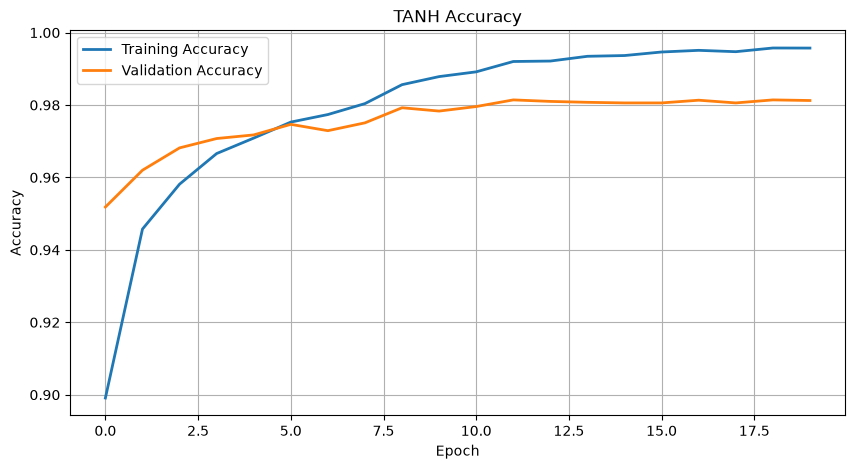

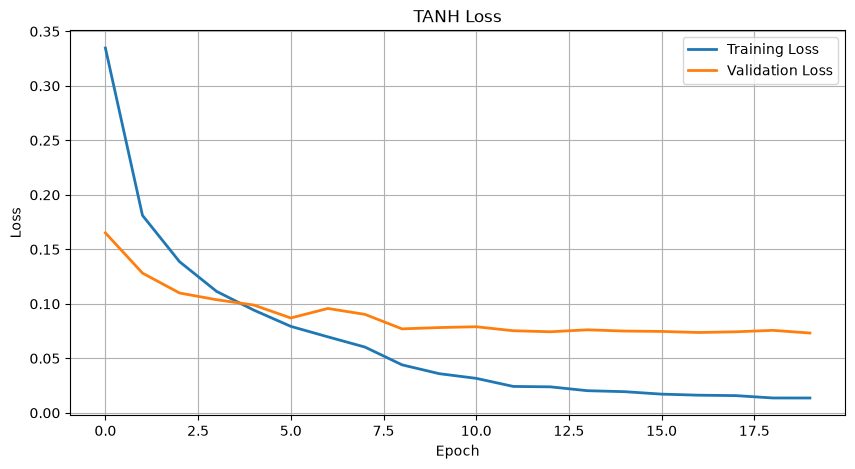

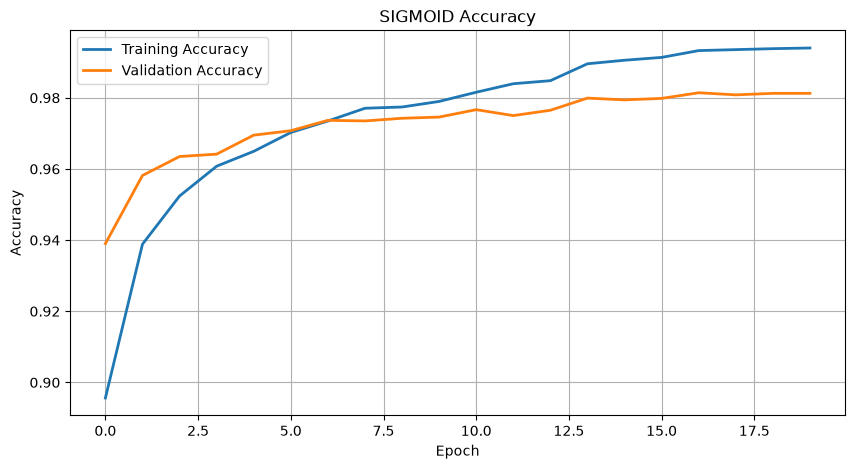

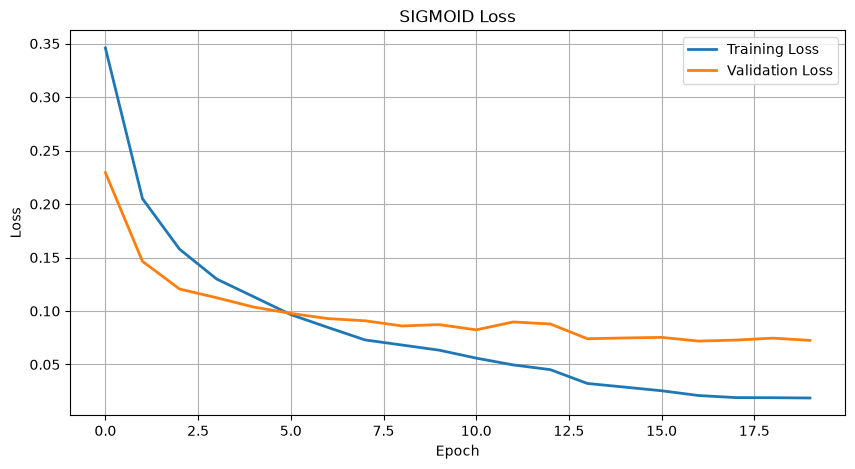

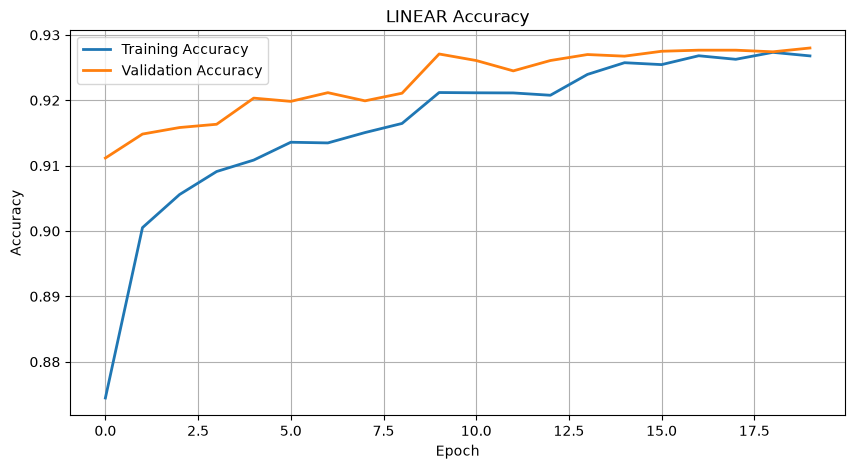

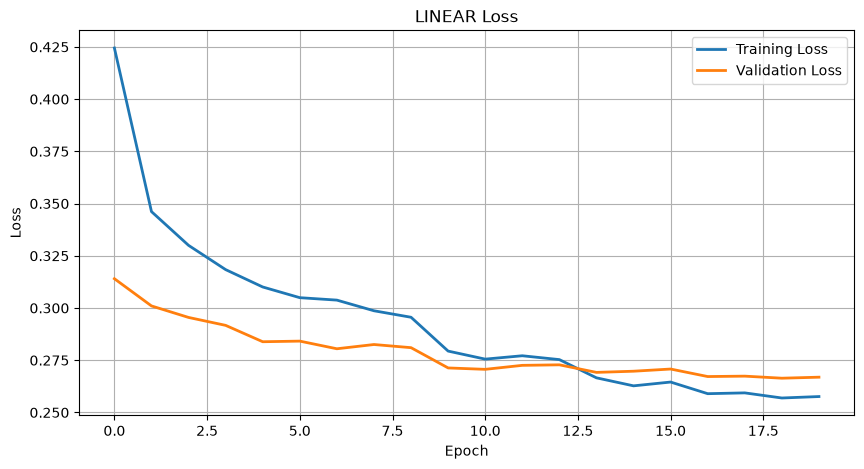

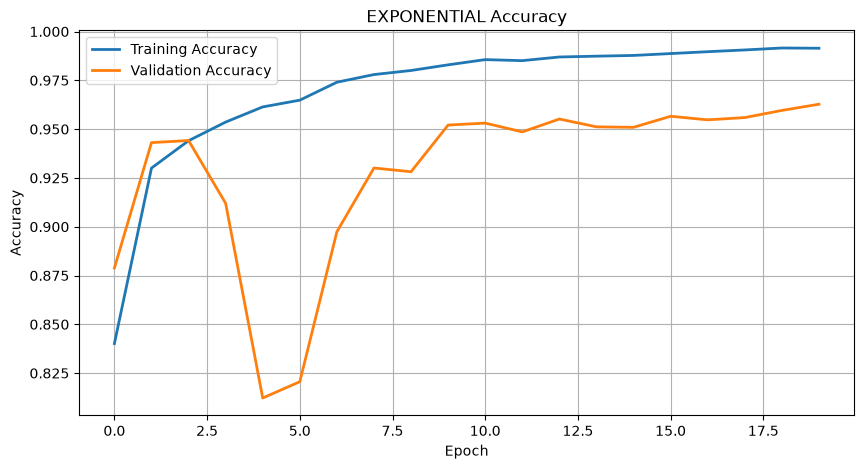

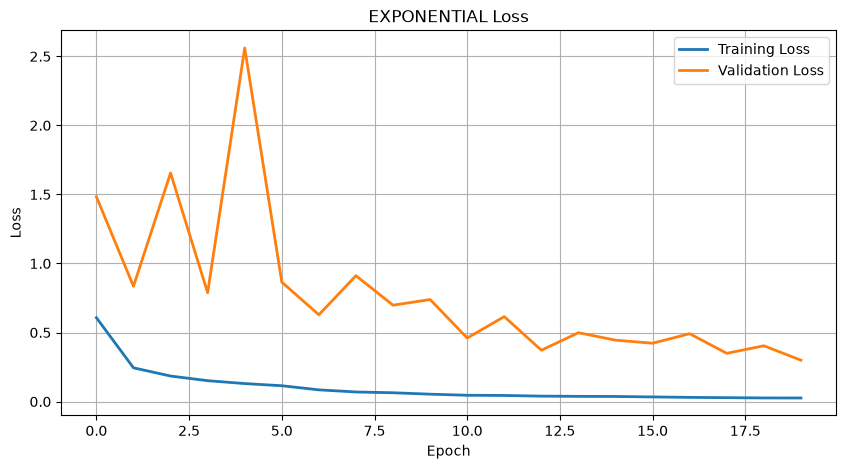

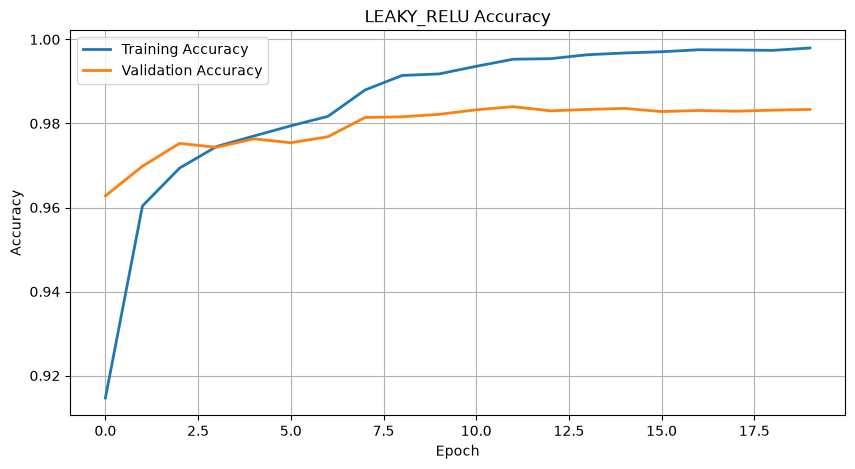

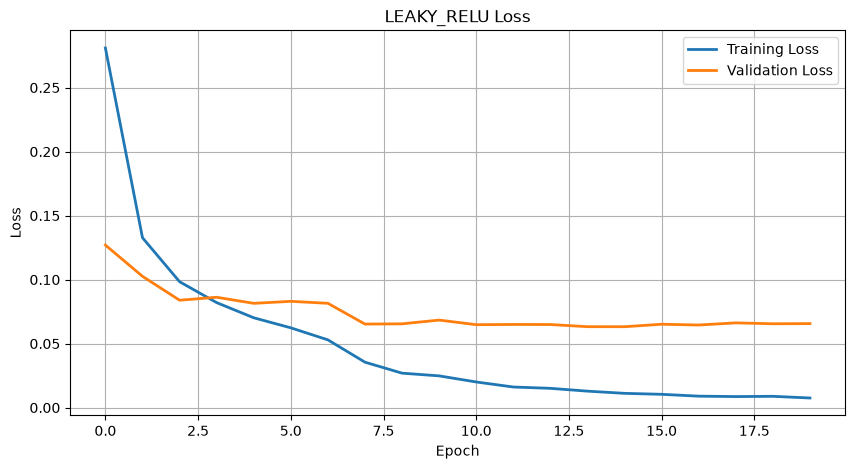

Accuracy/Loss Graphs Saved.


In [7]:
# ============================================================
# Plot Accuracy & Loss Curves
# ============================================================

print("\nGenerating Accuracy/Loss Graphs...")

for activation in history_dict.keys():

    history = history_dict[activation]

    # ---------------- Accuracy ----------------

    plt.figure(figsize=(10,5))

    plt.plot(
        history["accuracy"],
        label="Training Accuracy",
        linewidth=2
    )

    plt.plot(
        history["val_accuracy"],
        label="Validation Accuracy",
        linewidth=2
    )

    plt.title(f"{activation.upper()} Accuracy")

    plt.xlabel("Epoch")

    plt.ylabel("Accuracy")

    plt.legend()

    plt.grid(True)

    plt.savefig(
        f"results/plots/{activation}_accuracy.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show() # Display the plot
    plt.close()

    # ---------------- Loss ----------------

    plt.figure(figsize=(10,5))

    plt.plot(
        history["loss"],
        label="Training Loss",
        linewidth=2
    )

    plt.plot(
        history["val_loss"],
        label="Validation Loss",
        linewidth=2
    )

    plt.title(f"{activation.upper()} Loss")

    plt.xlabel("Epoch")

    plt.ylabel("Loss")

    plt.legend()

    plt.grid(True)

    plt.savefig(
        f"results/plots/{activation}_loss.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show() # Display the plot
    plt.close()

print("Accuracy/Loss Graphs Saved.")

In [8]:
# ============================================================
# Accuracy Comparison
# ============================================================

plt.figure(figsize=(10,6))

plt.bar(
    results_df["Activation"],
    results_df["Accuracy"]
)

plt.title("Activation Function Comparison")

plt.xlabel("Activation Function")

plt.ylabel("Accuracy")

plt.xticks(rotation=45)

plt.grid(axis="y")

plt.tight_layout()

plt.savefig(
    "results/plots/accuracy_comparison.png",
    dpi=300
)

plt.close()


# ============================================================
# F1 Score Comparison
# ============================================================

plt.figure(figsize=(10,6))

plt.bar(
    results_df["Activation"],
    results_df["F1 Score"]
)

plt.title("F1 Score Comparison")

plt.xlabel("Activation Function")

plt.ylabel("F1 Score")

plt.xticks(rotation=45)

plt.grid(axis="y")

plt.tight_layout()

plt.savefig(
    "results/plots/f1_comparison.png",
    dpi=300
)

plt.close()


# ============================================================
# Training Time Comparison
# ============================================================

plt.figure(figsize=(10,6))

plt.bar(
    results_df["Activation"],
    results_df["Training Time"]
)

plt.title("Training Time Comparison")

plt.xlabel("Activation Function")

plt.ylabel("Seconds")

plt.xticks(rotation=45)

plt.grid(axis="y")

plt.tight_layout()

plt.savefig(
    "results/plots/training_time.png",
    dpi=300
)

plt.close()

print("Comparison Graphs Saved.")

Comparison Graphs Saved.


In [9]:
# ============================================================
# Final Ranking
# ============================================================

print("\n")
print("=" * 70)
print("FINAL RANKING")
print("=" * 70)

ranking = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

print(ranking)

print("\nBest Activation Function")
print("--------------------------")

best = ranking.iloc[0]

print("Activation :", best["Activation"])
print("Accuracy   :", round(best["Accuracy"],4))
print("Precision  :", round(best["Precision"],4))
print("Recall     :", round(best["Recall"],4))
print("F1 Score   :", round(best["F1 Score"],4))

print("\n")
print("=" * 70)
print("PROJECT COMPLETED SUCCESSFULLY")
print("=" * 70)



FINAL RANKING
    Activation  Accuracy  Precision  Recall  F1 Score      Loss  Training Time
5   leaky_relu    0.9861   0.986117  0.9861  0.986100  0.054016      33.484609
0         relu    0.9848   0.984818  0.9848  0.984804  0.055280      22.451373
1         tanh    0.9825   0.982507  0.9825  0.982493  0.066201      30.161792
2      sigmoid    0.9799   0.979922  0.9799  0.979894  0.066440      31.598295
4  exponential    0.9637   0.965679  0.9637  0.963742  0.309980      32.950322
3       linear    0.9252   0.924977  0.9252  0.924934  0.270695      31.438304

Best Activation Function
--------------------------
Activation : leaky_relu
Accuracy   : 0.9861
Precision  : 0.9861
Recall     : 0.9861
F1 Score   : 0.9861


PROJECT COMPLETED SUCCESSFULLY
